# 03 · Feature Engineering & Modeling 

**Notebook:** 03 

**Goal:** 
- Select and clean the RFM features that will be fed into the clustering pipeline.
- Cluster customers into meaningful segments using machine learning, evaluate cluster quality, name segments and produce the final segmented customer table.

### What this notebook covers
- Drop unnecessary columns (dates, CustomerID) and rename for clarity
- Full pipeline: Yeo-Johnson → RobustScaler → KMeans
- test multiple sizes of clusters 
- Cluster profiling: statistical summary per segment and Name clusters


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# for plotly visualizations in SVG format for github
import plotly.io as pio
pio.renderers.default = 'svg'

In [3]:
# ── Load Reay RFM_analysis table from notebook 02 ─────────────────────────
rfm_analysis = pd.read_csv('/Users/mohammedmahmood/Documents/Data projects/Projects/Data science/Unsupervised proj/Online Retail Customer Segmentation RFM Analysis/data/3_RFM_for_analysis.csv')

rfm_analysis.head()

,CustomerID,Number_of_Orders,Total_Spend,Total_Items_Purchased,Product_Diversity,Days_Since_Last_Purchase,Customer_Lifetime_Days,Average_Order_Value
0,12346.0,12,77556.46,74285,27,326,400,6463.038333
1,12347.0,8,4921.53,2967,126,2,402,615.191250
2,12348.0,5,2019.40,2714,25,75,362,403.880000
3,12349.0,4,4428.69,1624,138,19,570,1107.172500
4,12350.0,1,334.40,197,17,310,0,334.400000


# **prepare RFM to modeling**

In [4]:
rfm_analysis.columns

Index(['CustomerID', 'Number_of_Orders', 'Total_Spend',
       'Total_Items_Purchased', 'Product_Diversity',
       'Days_Since_Last_Purchase', 'Customer_Lifetime_Days',
       'Average_Order_Value'],
      dtype='object')

### **Drop unnecessary columns for modeling and keep only the main three (Frequency, Monetary, Recency).**


In [5]:
rfm_analysis.rename(columns={
    "Frequency": "Number_of_Orders",
    "Monetary": "Total_Spend",
    "Recency": "Days_Since_Last_Purchase",

    "TotalQuantity": "Total_Items_Purchased",
    "UniqueProducts": "Product_Diversity",

    "CustomerLifetime": "Customer_Lifetime_Days",
    "AvgOrderValue": "Average_Order_Value"
}, inplace=True)

In [6]:
# drop unnceccry columns 
rfm_model = (
    rfm_analysis
    .drop(columns=[
        "CustomerID",
        "Total_Items_Purchased",
        "Product_Diversity",
        "Customer_Lifetime_Days",
        "Average_Order_Value"
    ])
)

rfm_model.head()

,Number_of_Orders,Total_Spend,Days_Since_Last_Purchase
0,12,77556.46,326
1,8,4921.53,2
2,5,2019.40,75
3,4,4428.69,19
4,1,334.40,310


In [7]:
rfm_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Number_of_Orders          5878 non-null   int64  
 1   Total_Spend               5878 non-null   float64
 2   Days_Since_Last_Purchase  5878 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 137.9 KB


# **modeling**

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

import scipy.cluster.hierarchy as sch
import plotly.figure_factory as ff
import plotly.graph_objects as go


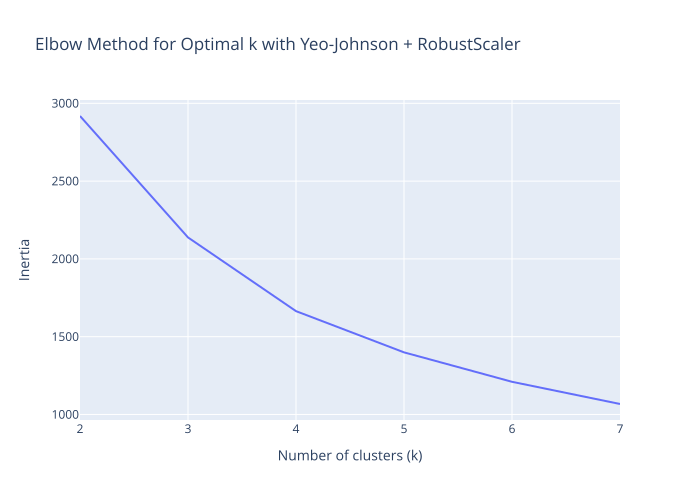

In [9]:
'''
- Yeo-Johnson transformation is applied to reduce skewness and make the feature distributions more Gaussian-like.
- RobustScaler is used to scale the data while reducing the influence of outliers.
- K-Means is trained for different values of k ranging from 2 to 8.
- The inertia value is recorded for each model.

- The optimal number of clusters is typically chosen at the elbow point, where adding more clusters results in only marginal improvements in inertia. 
This provides a balance between model simplicity and cluster quality.
'''

# Elbow Method to determine optimal k
inertia = []
k_values = range(2, 8 )
for k in k_values:
    steps =[]
    steps.append(('yeojohnson', PowerTransformer(method='yeo-johnson')))
    steps.append(('scaler',RobustScaler()))
    steps.append(('model',KMeans(n_clusters=k )))
    pipeline = Pipeline(steps=steps)
    pipeline.fit(rfm_model)
    inertia.append(pipeline['model'].inertia_)


# Plotting the elbow curve
fig = px.line(
    x=k_values,
    y=inertia,
    labels={'x': 'Number of clusters (k)', 'y': 'Inertia'},
    title='Elbow Method for Optimal k with Yeo-Johnson + RobustScaler'
)
fig.show()

In [10]:
# pip install kneed

# using elbow to determinied best number of K outomatically
from kneed import KneeLocator

k = KneeLocator(x = k_values , y=inertia,direction='decreasing',curve='convex')

elbow = k.elbow
elbow

4

In [11]:
"""
Evaluate K-Means clustering using Silhouette Score.
Higher scores indicate better-separated and more compact clusters.
The optimal k is chosen based on both score performance and business value.
"""


from sklearn.metrics import silhouette_score

cluster_range = range(2, 10)
silhouette_scores = []

for k in cluster_range:

    pipeline = Pipeline([
        ('yeojohnson', PowerTransformer(method='yeo-johnson')),
        ('scaler', RobustScaler()),
        ('model', KMeans( n_clusters=k, random_state=42, n_init=10 ))
    ])

    pipeline.fit(rfm_model)

    # Cluster labels
    labels = pipeline.named_steps['model'].labels_

    # Transformed data
    X_transformed = pipeline[:-1].transform(rfm_model)

    # Silhouette Score
    score = silhouette_score( X_transformed, labels )

    silhouette_scores.append(score)

    print(
        f'k={k} | '
        f'Silhouette={score:.3f}'
    )

k=2 | Silhouette=0.435
k=3 | Silhouette=0.345
k=4 | Silhouette=0.370
k=5 | Silhouette=0.339
k=6 | Silhouette=0.312
k=7 | Silhouette=0.310
k=8 | Silhouette=0.300
k=9 | Silhouette=0.288


### **Final Pipeline with All Transformations and the Best Number of Clusters to Apply**

- The elbow method and silhouette scores indicates that the best number of clusters is 4, but we will test 3, 4, and 5 and choose the one that gives the best business interpretability.

In [12]:
steps = []
steps.append(('yeojohnson', PowerTransformer(method='yeo-johnson')))
steps.append(('scaler', RobustScaler()))
steps.append(('model', KMeans(n_clusters= 4, random_state=42)))

# Create pipeline
Final_pipeline = Pipeline(steps=steps)

# Fit pipeline
Final_pipeline.fit(rfm_model)

Pipeline(steps=[('yeojohnson', PowerTransformer()), ('scaler', RobustScaler()),
                ('model', KMeans(n_clusters=4, random_state=42))])

### **Cluster labels from model**


In [13]:
# Cluster labels from model
labels = Final_pipeline.named_steps['model'].labels_

unique_clusters = np.unique(labels)
unique_clusters


array([0, 1, 2, 3], dtype=int32)

In [14]:
# assign cluster labels to original data
rfm_model['cluster'] = Final_pipeline.predict(rfm_model)

### Merge CustomerID back into clustered dataframe to save and use it

**Why?**
- CustomerID is needed to:
  - Identify real customers
  - Link clusters back to actual business data
  - Show personalized results in the dashboard / app
  - Allow the business team to take action (e.g., target specific customers in marketing campaigns)

In [15]:
# Merge the CustomerID to RFM table after modeling
rfm_model['CustomerID'] = rfm_analysis['CustomerID'].values

In [16]:
rfm_model.CustomerID.dtype

dtype('float64')

In [17]:
rfm_model.CustomerID.convert_dtypes(int)

0       12346
1       12347
2       12348
3       12349
4       12350
        ...  
5873    18283
5874    18284
5875    18285
5876    18286
5877    18287
Name: CustomerID, Length: 5878, dtype: Int64

# **clusters analysis**
### to see our model and clusters are good and have meaning or not

###  **1. Cluster Size & Distribution**

In [18]:
rfm_model["cluster"].value_counts(normalize= True)

cluster
2    0.279006
1    0.261824
3    0.229670
0    0.229500
Name: proportion, dtype: float64

#### **2. Apply statistical analysis on each cluster to better understand the characteristics and patterns of customers in every group.**

In [19]:
cluster_profile = (
    rfm_model
    .groupby("cluster")
    .agg(
    customers=("cluster", "count"),

        total_orders=("Number_of_Orders", "sum"),
        avg_orders=("Number_of_Orders", "mean"),

        total_spend=("Total_Spend", "sum"),
        avg_spend=("Total_Spend", "mean"),

        avg_recency_days=("Days_Since_Last_Purchase", "mean"),
    )
    .round(2)
)

# Customer share %
cluster_profile["customer_%"] = (
    cluster_profile["customers"]
    / cluster_profile["customers"].sum()
    * 100
).round(1)

# Revenue share %
cluster_profile["revenue_%"] = (
    cluster_profile["total_spend"]
    / cluster_profile["total_spend"].sum()
    * 100
).round(1)

# Revenue per customer
cluster_profile["avg_revenue_per_customer"] = (
    cluster_profile["total_spend"]
    / cluster_profile["customers"]
).round(2)

# Orders per customer
cluster_profile["avg_orders_per_customer"] = (
    cluster_profile["total_orders"]
    / cluster_profile["customers"]
).round(2)

cluster_profile = cluster_profile.sort_values(
    by="total_spend",
    ascending=False
)

cluster_profile

,customers,total_orders,avg_orders,total_spend,avg_spend,avg_recency_days,customer_%,revenue_%,avg_revenue_per_customer,avg_orders_per_customer
cluster,,,,,,,,,,
1,1539,25381,16.49,14010098.76,9103.38,38.53,26.2,80.6,9103.38,16.49
0,1349,5308,3.93,1868709.41,1385.26,314.16,22.9,10.8,1385.26,3.93
3,1350,4261,3.16,1106942.75,819.96,37.11,23.0,6.4,819.96,3.16
2,1640,2019,1.23,389053.34,237.23,396.48,27.9,2.2,237.23,1.23


# Customer Segmentation Summary (K = 4)

After evaluating multiple clustering solutions, the **4-cluster segmentation** was selected because it provides the best balance between customer behavior differentiation, revenue insights, and marketing actionability.

## Key Findings

The customer base shows a highly concentrated revenue distribution:

* **26.2% of customers generate 80.6% of total revenue**, representing the business's core customer base.
* Two groups have similar purchasing frequency but differ significantly in recency, allowing us to distinguish active customers from customers at risk of churn.
* The segmentation creates clear business-focused customer profiles that can be targeted with different retention and growth strategies.

## Final Customer Segments

### Cluster 1 – VIP Champions

* **26.2% of customers**
* **80.6% of revenue**
* Highest average spending and purchase frequency
* Recently active customers

**Business Interpretation:**
These customers are the primary revenue drivers and should receive the highest retention priority through loyalty programs, personalized offers, and premium customer experiences.

---

### Cluster 3 – Active Mid-Value Customers

* **23.0% of customers**
* **6.4% of revenue**
* Moderate spending and purchasing activity
* Recently active

**Business Interpretation:**
This segment represents the strongest growth opportunity. Cross-selling, upselling, and loyalty incentives can help move these customers toward the VIP segment.

---

### Cluster 0 – At-Risk High-Potential Customers

* **22.9% of customers**
* **10.8% of revenue**
* Historically valuable customers
* High recency indicates reduced engagement

**Business Interpretation:**
These customers show signs of churn despite previously contributing meaningful revenue. Targeted reactivation and win-back campaigns should be prioritized.

---

### Cluster 2 – Low-Value & Inactive Customers

* **27.9% of customers**
* **2.2% of revenue**
* Lowest spending and purchase frequency
* Highest recency

**Business Interpretation:**
These customers contribute little revenue and should be managed using low-cost automated marketing campaigns while minimizing expensive retention efforts.

## Conclusion

The 4-cluster solution provides a clear and actionable customer segmentation framework. The analysis highlights a classic Pareto pattern in which a relatively small group of customers contributes the majority of revenue. Business efforts should focus on:

1. Retaining and growing **VIP Champions**.
2. Converting **Active Mid-Value Customers** into higher-value customers.
3. Re-engaging **At-Risk High-Potential Customers** before they churn.
4. Managing **Low-Value & Inactive Customers** with cost-efficient campaigns.

This segmentation can support customer relationship management (CRM), retention strategies, personalized marketing campaigns, and resource allocation decisions.


### Rename clusters after analysis

In [20]:
Cluster_Names = {
    1: "Revenue Drivers",
    3: "Growth Segment",
    0: "Retention Risk Customers",
    2: "Inactive",
}

# Add the cluster name column to data frame
rfm_model['cluster_name'] = rfm_model['cluster'].map(Cluster_Names)


In [21]:
fm_model = rfm_model.rename(columns={
    'cluster': 'group',
    'cluster_name': 'group_name'
})


In [22]:
cluster_profile

,customers,total_orders,avg_orders,total_spend,avg_spend,avg_recency_days,customer_%,revenue_%,avg_revenue_per_customer,avg_orders_per_customer
cluster,,,,,,,,,,
1,1539,25381,16.49,14010098.76,9103.38,38.53,26.2,80.6,9103.38,16.49
0,1349,5308,3.93,1868709.41,1385.26,314.16,22.9,10.8,1385.26,3.93
3,1350,4261,3.16,1106942.75,819.96,37.11,23.0,6.4,819.96,3.16
2,1640,2019,1.23,389053.34,237.23,396.48,27.9,2.2,237.23,1.23


In [23]:
rfm_model.head()

,Number_of_Orders,Total_Spend,Days_Since_Last_Purchase,cluster,CustomerID,cluster_name
0,12,77556.46,326,1,12346.0,Revenue Drivers
1,8,4921.53,2,1,12347.0,Revenue Drivers
2,5,2019.40,75,0,12348.0,Retention Risk Customers
3,4,4428.69,19,1,12349.0,Revenue Drivers
4,1,334.40,310,2,12350.0,Inactive


In [24]:
# Reorder columns
rfm_model = rfm_model[['CustomerID', 'Number_of_Orders', 'Total_Spend', 'Days_Since_Last_Purchase', 'cluster', 'cluster_name']]

In [25]:
# Save cluster_profile to CSV to use in streamlit 

# cluster_profile.to_csv("clusters_profile.csv", index=False)

In [26]:
# ── Save final segment tables (Final Rfm table with clusters) ───────────────────

# rfm_model.to_csv("4_Final_segments.csv", index=False)